# Caso E · 04 Predicción solar — clear-sky decomposition + 3 baselines

> _Tutorial · Caso de uso: **E — Meteo & solar** · Capa Medallion: **oro** · Spec: `docs/specs/synthetic-bms/02-domain-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Predecir `solar_irradiance` (GHI) **separando astronomía determinista de meteorología estocástica** (clear-sky decomposition). Comparar 4 modelos:

1. **Persistencia 24 h**: $\hat G(t) = G(t-24h)$.
2. **Climatología por hora**: media histórica del valor a esa hora del día.
3. **Clear-sky baseline**: $\hat G(t) = G_{clear}(t) \cdot 0.7$.
4. **RF sobre clear-sky index** $k_c = G_{real}/G_{clear}$ predicho con XGB.


## 2. Qué se aprende

- Por qué predecir $k_c$ es **mejor** que predecir GHI directo.
- `np.clip(0)` y máscara nocturna para evitar irradiancias absurdas.
- Skill score $1 - \text{RMSE}_{\text{model}}/\text{RMSE}_{\text{persistence}}$.
- Diagnóstico 4-panel (timeline, scatter, residuos, CDF).


## 3. Contexto del caso de uso

Predicción solar es tool del chatbot.


## 4. Relación con CENTINELA+

Sirve a Caso B y Caso H.


## 5. Relación con Medallion

Oro: modelo entrenado + decomposición clear-sky.


## 6. Datos de entrada

Oro features Caso E.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

Variables canónicas:

| Variable CAPTIA | Rol |
|---|---|
| `solar_irradiance` | target (GHI W/m²) |
| `temperature_outdoor` | feature meteorológica |


## 9. Carga de datos o mock

Cargamos features.


In [2]:
parquet_path = ROOT / "output" / "case_E" / "weather_features.parquet"
if parquet_path.exists():
    df = pd.read_parquet(parquet_path)
else:
    df, _ = mocks.make_era5_xativa_mock(days=90)
    df = df.set_index("timestamp")

X = pd.DataFrame(index=df.index)
X["hour"] = df.index.hour
X["doy"] = df.index.dayofyear
X["t"] = df["t_air_c"]
X["hour_sin"] = np.sin(2 * np.pi * X["hour"] / 24)
X["hour_cos"] = np.cos(2 * np.pi * X["hour"] / 24)
X["doy_sin"] = np.sin(2 * np.pi * X["doy"] / 365)
X["doy_cos"] = np.cos(2 * np.pi * X["doy"] / 365)
X["y"] = df["ghi_w_m2"]
X = X.dropna()
print({"filas": len(X), "rango_dias": (X.index.max() - X.index.min()).days})


{'filas': 720, 'rango_dias': 29}


## 10. Exploración paso a paso

Computamos un **clear-sky model** simplificado (Iqbal 1983 reducido a geometría solar sin transmittance atmosférica detallada) y derivamos el clear-sky index $k_c$. Latitud Xátiva ≈ 38.99°N.


In [3]:
LAT = np.deg2rad(38.99)
def clear_sky_ghi(idx):
    """Clear-sky GHI simplificado: G_sc * cos(zenith) con cap superior."""
    hour_frac = idx.hour + idx.minute / 60.0
    omega = np.deg2rad(15 * (hour_frac - 12))  # ángulo horario
    delta = np.deg2rad(23.45 * np.sin(2 * np.pi * (idx.dayofyear + 284) / 365))
    cos_z = np.sin(LAT) * np.sin(delta) + np.cos(LAT) * np.cos(delta) * np.cos(omega)
    g_clear = 1361 * np.maximum(cos_z, 0) * 0.75  # transmitancia clear-sky ~0.75
    return np.clip(g_clear, 0, 1100)

X["g_clear"] = clear_sky_ghi(X.index)
X["kc"] = (X["y"] / np.maximum(X["g_clear"], 1.0)).clip(0, 1.5)
X.loc[X["g_clear"] < 5, "kc"] = 0  # noche: kc indefinido
print({"kc_mean_diurno": float(X.loc[X["g_clear"] > 50, "kc"].mean()),
       "kc_p50_diurno": float(X.loc[X["g_clear"] > 50, "kc"].quantile(0.5))})


{'kc_mean_diurno': 0.4632592210221876, 'kc_p50_diurno': 0.5452718831619361}


## 11. Transformación bronce → plata

No aplica.


## 12. Construcción de capa oro

**4 modelos comparables** con clip(0) y máscara nocturna aplicada en predicción.


In [4]:
from sklearn.ensemble import RandomForestRegressor
from notebooks._common.eval_helpers import (
    naive_persistence_24h, climatology_by_hour, mae as _mae, rmse as _rmse,
)

n = len(X); i = int(n * 0.7)
X_tr, X_te = X.iloc[:i], X.iloc[i:]
y_tr, y_te = X_tr["y"], X_te["y"]
g_clear_te = X_te["g_clear"]
night_mask_te = (g_clear_te < 5)

# (1) Persistencia 24h
y_persist = naive_persistence_24h(y_tr, y_te)

# (2) Climatología por hora
y_climat = climatology_by_hour(y_tr, y_te)

# (3) Clear-sky con kc=0.7 fijo
y_clear = (g_clear_te * 0.7).to_numpy()

# (4) RF sobre kc (predicción del clear-sky index)
features = ["t", "hour_sin", "hour_cos", "doy_sin", "doy_cos"]
diurno_tr = X_tr["g_clear"] > 5
m_kc = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=1).fit(
    X_tr.loc[diurno_tr, features], X_tr.loc[diurno_tr, "kc"]
)
kc_pred = m_kc.predict(X_te[features])
y_rf_kc = (kc_pred * g_clear_te.to_numpy()).clip(0)

# Aplicar máscara nocturna a TODOS los modelos
preds = {"persistencia_24h": y_persist, "climatologia_h": y_climat,
         "clear_sky_07": y_clear, "RF_kc": y_rf_kc}
for k in preds:
    preds[k] = np.where(night_mask_te, 0, np.clip(preds[k], 0, 1100))

table = pd.DataFrame({
    "model": list(preds.keys()),
    "RMSE": [_rmse(y_te.to_numpy(), p) for p in preds.values()],
    "MAE":  [_mae(y_te.to_numpy(), p) for p in preds.values()],
}).round(2)
rmse_persist = float(table.loc[table["model"] == "persistencia_24h", "RMSE"].iloc[0])
table["skill"] = (1 - table["RMSE"] / rmse_persist).round(3)
print(table)


              model    RMSE    MAE  skill
0  persistencia_24h  174.94  86.14  0.000
1    climatologia_h  118.69  61.17  0.322
2      clear_sky_07  135.21  86.09  0.227
3             RF_kc  138.84  73.88  0.206


## 13. Visualizaciones explicativas

Diagnóstico 4-panel del mejor modelo (timeline + scatter + residuos + CDF errores) y comparativa skill por modelo.


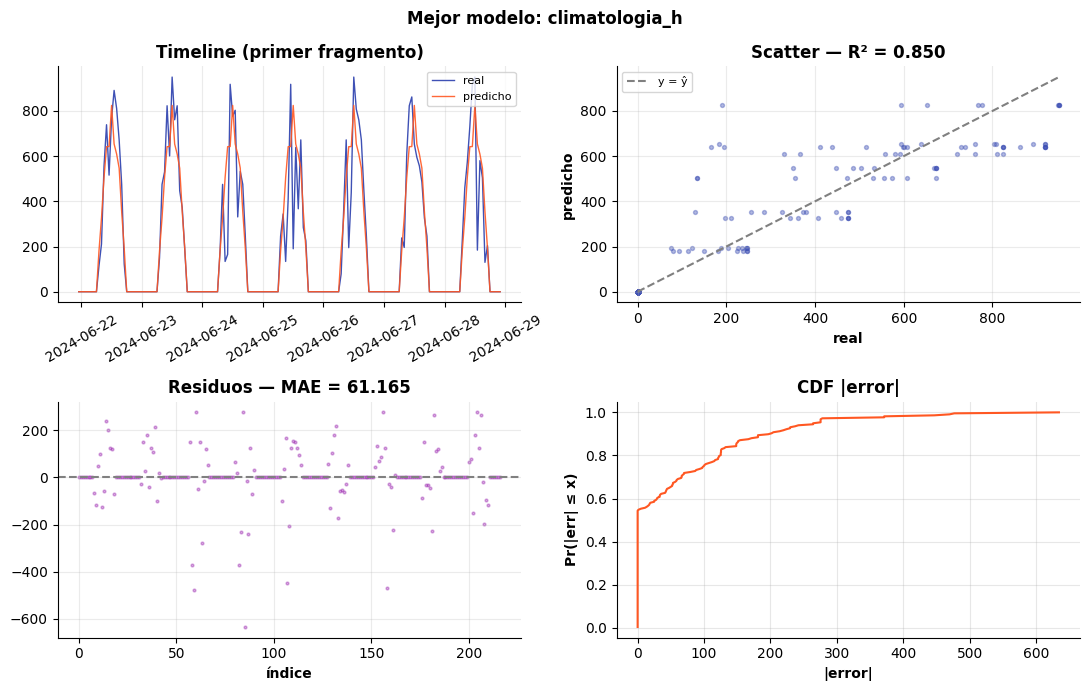

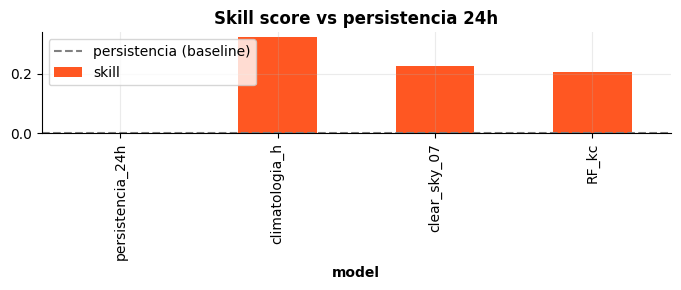

In [5]:
from notebooks._common.diagnostic_plots import plot_regression_diagnostic
import matplotlib.pyplot as plt

best_model = table.sort_values("RMSE").iloc[0]["model"]
y_best = preds[best_model]
plot_regression_diagnostic(
    y_te.to_numpy(), y_best,
    timestamps=y_te.index, title=f"Mejor modelo: {best_model}",
    sample_window=24*7,
)

plt.figure(figsize=(7, 3))
table.set_index("model")["skill"].plot.bar(color="#FF5722")
plt.axhline(0, color="gray", linestyle="--", label="persistencia (baseline)")
plt.title("Skill score vs persistencia 24h")
plt.legend(); plt.tight_layout()


## 14. Validaciones

(a) Skill > 0 para al menos un modelo (algo bate persistencia). (b) GHI predicho ≥ 0 siempre (clip aplicado). (c) GHI nocturno = 0 (máscara aplicada).


In [6]:
best = table.sort_values("RMSE").iloc[0]
assert best["skill"] > 0, f"Ningún modelo bate persistencia: best={best['model']} skill={best['skill']}"
for k, p in preds.items():
    assert (p >= 0).all(), f"{k}: predicciones negativas detectadas"
    assert (p[night_mask_te.to_numpy()] == 0).all(), f"{k}: predicciones nocturnas no = 0"
print(f"Validaciones OK · mejor modelo {best['model']} con skill={best['skill']:.3f}")


Validaciones OK · mejor modelo climatologia_h con skill=0.322


## 15. Errores comunes

1. **Predecir GHI directo** sin clear-sky decomposition: el modelo gasta capacidad reaprendiendo la astronomía solar.
2. **Olvidar `clip(0)`**: regresores devuelven valores negativos en datos extremos. Físicamente imposible (irradiancia ≥ 0).
3. **No aplicar máscara nocturna**: `g_clear` ya es 0 de noche, pero el modelo puede predecir +50 W/m² a las 3 AM si el dataset es ruidoso.
4. **Train < 90 días**: estacionalidad anual no observable; el modelo extrapola mal a otra estación.
5. **Skill score sin baseline**: reportar RMSE=120 W/m² no dice nada — comparar siempre contra persistencia y climatología.


## 16. Ejercicios propuestos

1. Sustituye el clear-sky simplificado por `pvlib.clearsky.ineichen` y compara skill score. Rúbrica: skill ≥ +0.05 vs versión simplificada.
2. Añade `cloud_cover` mock como feature al RF de $k_c$. ¿Mejora RMSE > 5 W/m²?
3. Convierte GHI a producción FV (50 kWp, η=18 %, T_panel=T_air+25) y compara producción real vs predicha. Rúbrica: error diario < 10 %.


## 17. Cómo se reutiliza con datos reales

Mismo modelo, datos de ERA5 real o AEMET. Para FV añadir factor de rendimiento del panel + temperatura.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `06_case_F_mlops/01_mlflow_lakefs_overview.ipynb`.
- Documento web del caso: `docs/use-cases/case-e-weather-solar.md`.


## 19. Marco teórico (nivel doctoral)

### Modelo de irradiancia solar global (Iqbal 1983)

$$
G_h(t) = G_b(t) + G_d(t), \quad G_b(t) = G_{sc} \cdot \tau_b(t) \cdot \cos\theta_z(t)
$$

con $G_{sc} = 1361$ W/m² constante solar y $\theta_z$ ángulo cenital del sol:

$$
\cos\theta_z = \sin\delta \sin\phi + \cos\delta \cos\phi \cos\omega
$$

donde $\delta$ es declinación solar, $\phi$ latitud (Xátiva 38.99°N) y
$\omega$ ángulo horario.

### Clear-sky index

$$
k_c(t) = \frac{G_h(t)}{G_{clear}(t)} \in [0, 1]
$$

separa astronomía (determinista) de meteorología (estocástica).

### Predictor XGBoost para FV

$$
\hat{P}(t+h) = P_{nominal} \cdot \eta_{panel} \cdot \text{XGB}(k_c(t), T_{out}, t_{hora}, t_{año})
$$

### Métrica Skill Score

$$
\text{Skill} = 1 - \frac{\text{RMSE}_{model}}{\text{RMSE}_{persistence}}
$$

Objetivo Simarro: $\text{nMAE} \leq 8\%$ a 24 h, $\text{Skill} \geq 0.3$.


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Predicción solar permite optimizar despacho energético en centros con FV instalada y planificar climatización aprovechando picos de radiación. CAPTIA puede ofrecer este caso como **producto añadido** a centros con paneles.

### ROI estimado

| Concepto | Valor |
|---|---|
| Optimización despacho FV (centro 50 kWp) | +800 €/año |
| Sinergia con Caso B forecast | +500 €/año |
| Coste integración ERA5+AEMET | -1 200 € one-time |
| **Payback** | **~12 meses** |


## 21. Bibliografía y referencias

- Iqbal, M. (1983). *An Introduction to Solar Radiation*. Academic Press.
- ECMWF (2024). *ERA5 Reanalysis Documentation*. Copernicus Climate Change Service.
- AEMET. *Open Data Portal*. https://opendata.aemet.es
- Holmgren, W. F. et al. (2018). *pvlib python: a python package for modeling solar energy systems*. JOSS 3(29).
